LoRe basis interpretability on PRISM                     
                                                             
  This notebook builds on Adaptive Pluralistic Alignment
  (Freedman et al., 2026). It does three things:               
                                                               
  1. Reproduces Figure 2 from APA's published K=8 LoRe
  checkpoint (no retraining).                                  
  2. Adds a basis-dominance analysis showing that despite the  
  visual impression of Figure 2, only 21% of the 182 PRISM     
  users have a clear winning basis — LoRe at K=8 produces      
  smooth mixtures, not discrete user archetypes.               
  3. Retrains from scratch to recover the user_id → row mapping
   (anonymous in the published checkpoint), enabling follow-up
  demographic interpretability work.                           
                                                    
  Parts 1 and 2 run in seconds. Part 3 takes ~2-4 hours on an  
  A100 and supports checkpoint-resume across Colab disconnects.
                                                    
  Repo: https://github.com/ifesiTinkering/LoRe_interp

In [ ]:
  !rm -rf LoRe_interp
  !git clone https://github.com/ifesiTinkering/LoRe_interp.git
  %cd LoRe_interp

Cloning into 'LoRe_interp'...
remote: Enumerating objects: 173, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (135/135), done.
remote: Total 173 (delta 43), reused 165 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (173/173), 7.09 MiB | 18.75 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/LoRe_interp


In [ ]:
  !pip install -q torch transformers datasets
  !pip install -q huggingface_hub matplotlib numpy pillow
  !pip install -q scikit-learn scipy networkx accelerate
  !pip install -q pyarrow tqdm sentencepiece safetensors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 18.1 MB/s eta 0:00:00


In [ ]:
  from huggingface_hub import login
  from google.colab import userdata
  login(token=userdata.get('HF_TOKEN'))
  print('HF login OK')

HF login OK


In [ ]:
  import torch
  print('CUDA:', torch.cuda.is_available())
  if torch.cuda.is_available():
      name = torch.cuda.get_device_name(0)
      vram = torch.cuda.get_device_properties(0).total_memory / 1e9
      print('Device:', name)
      print('VRAM GB:', round(vram, 1))

CUDA: True
Device: NVIDIA A100-SXM4-80GB
VRAM GB: 85.1


In [ ]:
  import torch
  import numpy as np
  W_path = 'apa/experiments/checkpoints/W_seen_K8.pt'
  W = torch.load(W_path, map_location='cpu',
  weights_only=False)
  W = W.float().numpy()
  n_users, K = W.shape
  print('W shape:', W.shape)

W shape: (182, 8)


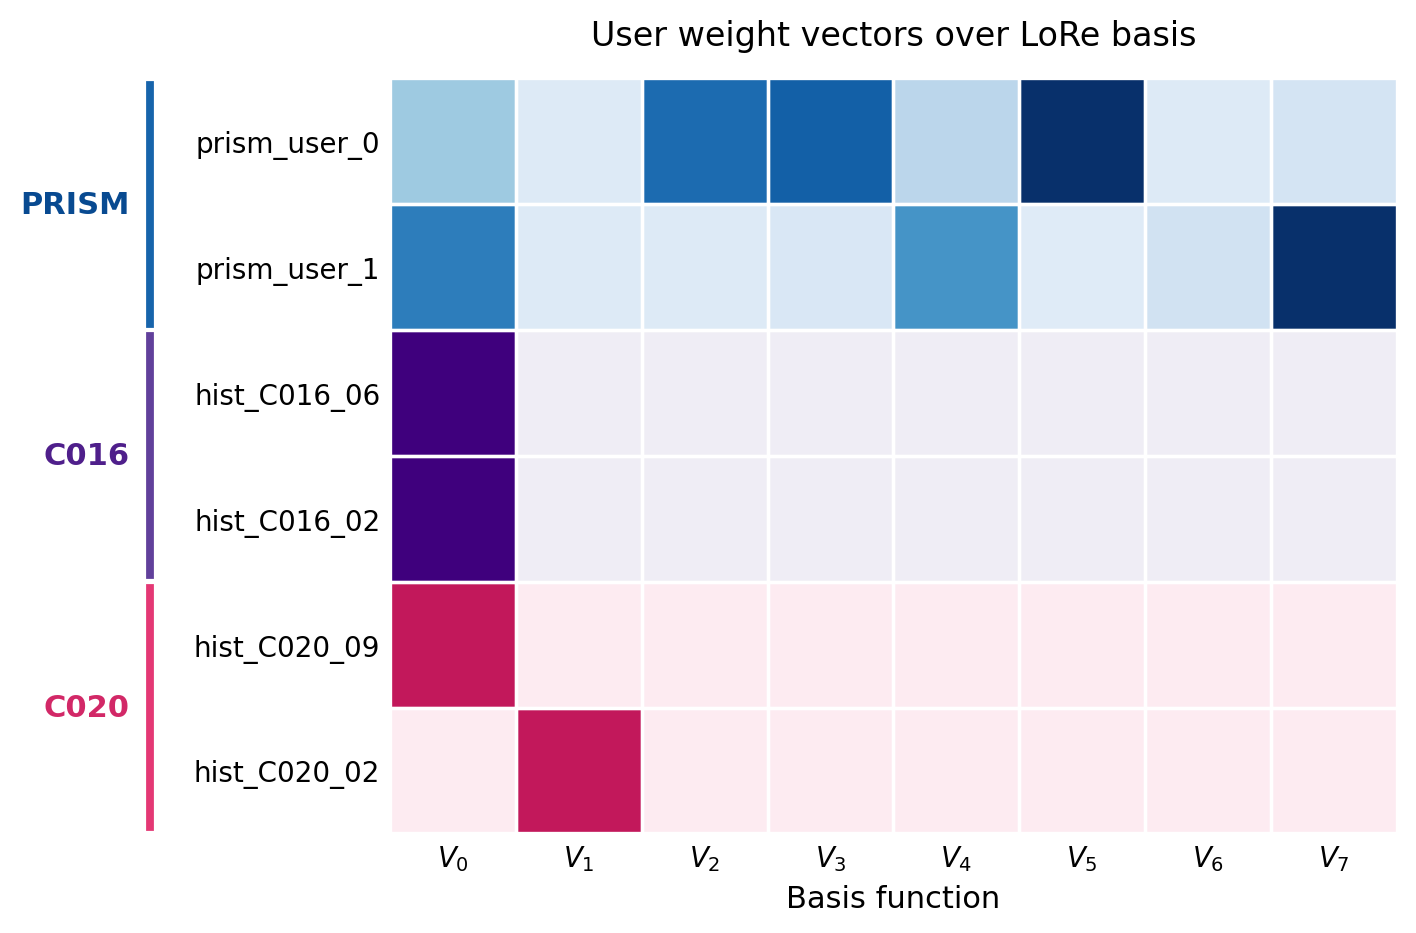

In [ ]:
  import sys, importlib
  from pathlib import Path
  sys.path.insert(0, 'apa')
  import apa.config as _cfg
  _cfg.MODELS_DIR = Path('apa/experiments/checkpoints')
  _figs = importlib.import_module('experiments.figs')
  _figs.FIGS_DIR = Path('out')
  _figs.FIGS_DIR.mkdir(parents=True, exist_ok=True)
  _figs.fig_user_weights_grid(K=8, save=True)
  from IPython.display import Image
  Image('out/user_weights_grid.png')

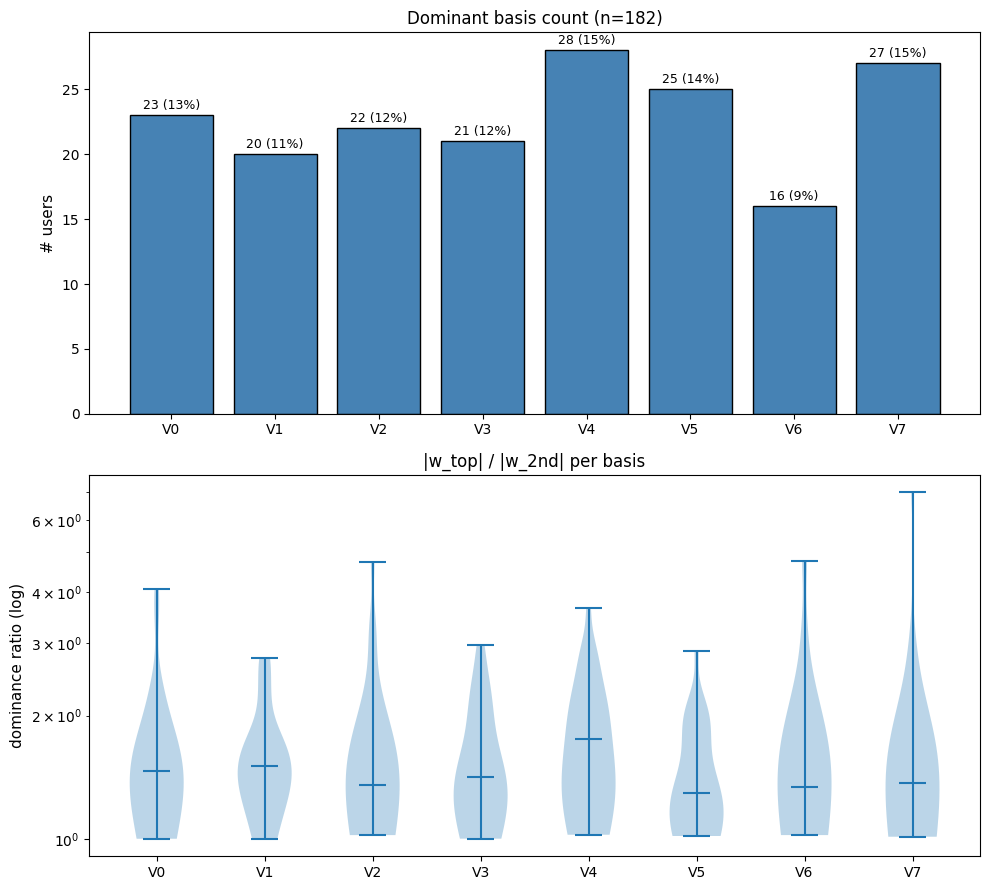

Median dominance: 1.41
Clear winners (>=2x): 39
Tied (<1.2x): 45
Total users: 182


In [ ]:
  import matplotlib.pyplot as plt
  absW = np.abs(W)
  top_basis = absW.argmax(axis=1)
  sorted_desc = np.sort(absW, axis=1)[:, ::-1]
  dom = sorted_desc[:, 0] / np.maximum(sorted_desc[:, 1],
  1e-12)
  counts = np.bincount(top_basis, minlength=K)

  fig, axes = plt.subplots(2, 1, figsize=(10, 9))
  ax1 = axes[0]
  ax1.bar(range(K), counts, color="steelblue",
  edgecolor="black")
  ax1.set_xticks(range(K))
  ax1.set_xticklabels(["V" + str(i) for i in range(K)])
  ax1.set_ylabel("# users")
  ax1.set_title("Dominant basis count (n=" + str(n_users) +
  ")")
  for i, c in enumerate(counts):
      pct = round(100 * c / n_users)
      label = str(c) + " (" + str(pct) + "%)"
      ax1.text(i, c + 0.5, label, ha="center", fontsize=9)

  ax2 = axes[1]
  non_empty = []
  for k in range(K):
      mask = top_basis == k
      if mask.any():
          non_empty.append((k, dom[mask]))
  positions = [k for k, _ in non_empty]
  data = [d for _, d in non_empty]
  ax2.violinplot(data, positions=positions, showmedians=True)
  ax2.set_xticks(range(K))
  ax2.set_xticklabels(["V" + str(i) for i in range(K)])
  ax2.set_ylabel("dominance ratio (log)")
  ax2.set_yscale("log")
  ax2.set_title("|w_top| / |w_2nd| per basis")
  plt.tight_layout()
  plt.show()

  print("Median dominance:", round(np.median(dom), 2))
  print("Clear winners (>=2x):", int((dom >= 2).sum()))
  print("Tied (<1.2x):", int((dom < 1.2).sum()))
  print("Total users:", n_users)

In [ ]:
!pip install -q transformers==4.45.0 --force-reinstall

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.


In [ ]:
!pip show transformers | grep Version

Version: 4.45.0


=== CELL 8 — run the full pipeline ===

In [ ]:
  import subprocess
  import shutil
  from pathlib import Path
  from google.colab import drive

  drive.mount('/content/drive')

  LOG = Path('checkpoints_retrained/run.log')
  LOG.parent.mkdir(parents=True, exist_ok=True)

  p = subprocess.Popen(
      ['python', '-u', 'run_full_pipeline.py'],
      stdout=subprocess.PIPE,
      stderr=subprocess.STDOUT,
      text=True,
      bufsize=1,
  )
  with open(LOG, 'a') as logf:
      for line in p.stdout:
          print(line, end='')
          logf.write(line)
  p.wait()
  print("Pipeline exit code:", p.returncode)

  dst_dir = Path('/content/drive/MyDrive/LoRe_interp_results')
  dst_dir.mkdir(parents=True, exist_ok=True)

  files = [
      'checkpoints_retrained/V_K8.pt',
      'checkpoints_retrained/W_seen_K8.pt',
      'checkpoints_retrained/seen_user_ids.json',
      'checkpoints_retrained/user_demographics.json',
      'checkpoints_retrained/embeddings/train.pkl',
      'checkpoints_retrained/embeddings/test.pkl',
      'checkpoints_retrained/prism_data/survey.jsonl',
      'checkpoints_retrained/prism_data/conversations.jsonl',
      'checkpoints_retrained/run.log',
  ]
  for f in files:
      src = Path(f)
      if not src.exists():
          print('Skip missing:', src)
          continue
      dst = dst_dir / src.name
      print('Copy', src, '->', dst)
      shutil.copy(src, dst)

  if p.returncode != 0:
      raise RuntimeError(f'Pipeline failed (exit {p.returncode}). See checkpoints_retrained/run.log for details.')

  print('All done.')

Streaming output truncated to the last 5000 lines.
Generating embeddings: 100%|██████████| 13011/13011 [47:29<00:00,  4.57it/s]
Traceback (most recent call last):
  File "/content/LoRe_interp/run_full_pipeline.py", line 168, in <module>
    if device.startswith("cuda"):
^^^^^^^^^^^^^^
  File "/content/LoRe_interp/run_full_pipeline.py", line 84, in step_2_save_metadata
    """
        
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 1500, in load
    with _open_file_like(f, "rb") as opened_file:
         ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 768, in _open_file_like
    return _open_file(name_or_buffer, mode)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/serialization.py", line 749, in __init__
    super().__init__(open(name, mode))  # noqa: SIM115
                     ^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/

RuntimeError: Failed: python run_full_pipeline.py

In [6]:
  from google.colab import drive
  drive.mount('/content/drive')


Mounted at /content/drive


In [7]:
  import json
  import numpy as np
  import torch
  from pathlib import Path

  DRIVE = Path('/content/drive/MyDrive/LoRe_interp_results')

  W = torch.load(DRIVE / 'W_seen_K8.pt', map_location='cpu',
  weights_only=False).float().numpy()
  with open(DRIVE / 'seen_user_ids.json') as f:
      user_ids = json.load(f)
  with open(DRIVE / 'user_demographics.json') as f:
      demo = json.load(f)

  n_users, K = W.shape
  print('W shape:', W.shape)
  print('Users:', len(user_ids))
  print('Demographics for:', len(demo))

W shape: (1030, 3)
Users: 1030
Demographics for: 1030


In [4]:
  with open(DRIVE / 'survey.jsonl') as f:
      for i, line in enumerate(f):
          d = json.loads(line)
          if i == 0:
              print('All keys in survey entry:')
              for k in d.keys():
                  print('  -', k)
          print('Entry', i, '- preference-like fields:')
          for k, v in d.items():
              if any(s in k.lower() for s in ['pref', 'value', 'rank', 'order']):
                  print(f'  {k}:', str(v)[:200])
          print('---')
          if i >= 2:
              break

All keys in survey entry:
  - user_id
  - survey_only
  - num_completed_conversations
  - consent
  - consent_age
  - lm_familiarity
  - lm_indirect_use
  - lm_direct_use
  - lm_frequency_use
  - self_description
  - system_string
  - age
  - gender
  - employment_status
  - education
  - marital_status
  - english_proficiency
  - study_id
  - study_locale
  - religion
  - ethnicity
  - location
  - lm_usecases
  - stated_prefs
  - order_lm_usecases
  - order_stated_prefs
  - generated_datetime
  - timing_duration_s
  - timing_duration_mins
  - included_in_US_REP
  - included_in_UK_REP
  - included_in_balanced_subset
Entry 0 - preference-like fields:
  stated_prefs: {'values': 83, 'creativity': 100, 'fluency': 100, 'factuality': 100, 'diversity': 100, 'safety': 90, 'personalisation': 71, 'helpfulness': 100, 'other': 50, 'other_text': None}
  order_lm_usecases: {'homework_assistance': 17, 'research': 6, 'source_suggestions': 10, 'professional_work': 8, 'creative_writing': 16, 'casual_co

In [5]:
  import json
  from collections import Counter

  user_to_top_pref = {}
  with open(DRIVE / 'survey.jsonl') as f:
      for line in f:
          d = json.loads(line)
          uid = d.get('user_id')
          order = d.get('order_stated_prefs', {})
          if order:
              user_to_top_pref[uid] = min(order.items(), key=lambda
   kv: kv[1])[0]

  LABEL_MAP = {
      'values': 'values',
      'creativity': 'creativity',
      'fluency': 'fluency',
      'factuality': 'factuality',
      'diversity': 'diversity',
      'safety': 'safety',
      'personalisation': 'personalisation',
      'helpfulness': 'helpfulness',
      'other': 'other',
      'unknown': 'unknown',
  }

  top_prefs = [user_to_top_pref.get(u, 'unknown') for u in
  user_ids]
  print('Top stated preference distribution:')
  for k, v in Counter(top_prefs).most_common():
      print(f'  {LABEL_MAP.get(k, k)}: {v}')

Top stated preference distribution:
  personalisation: 153
  diversity: 140
  safety: 136
  factuality: 135
  fluency: 127
  helpfulness: 126
  values: 119
  creativity: 94


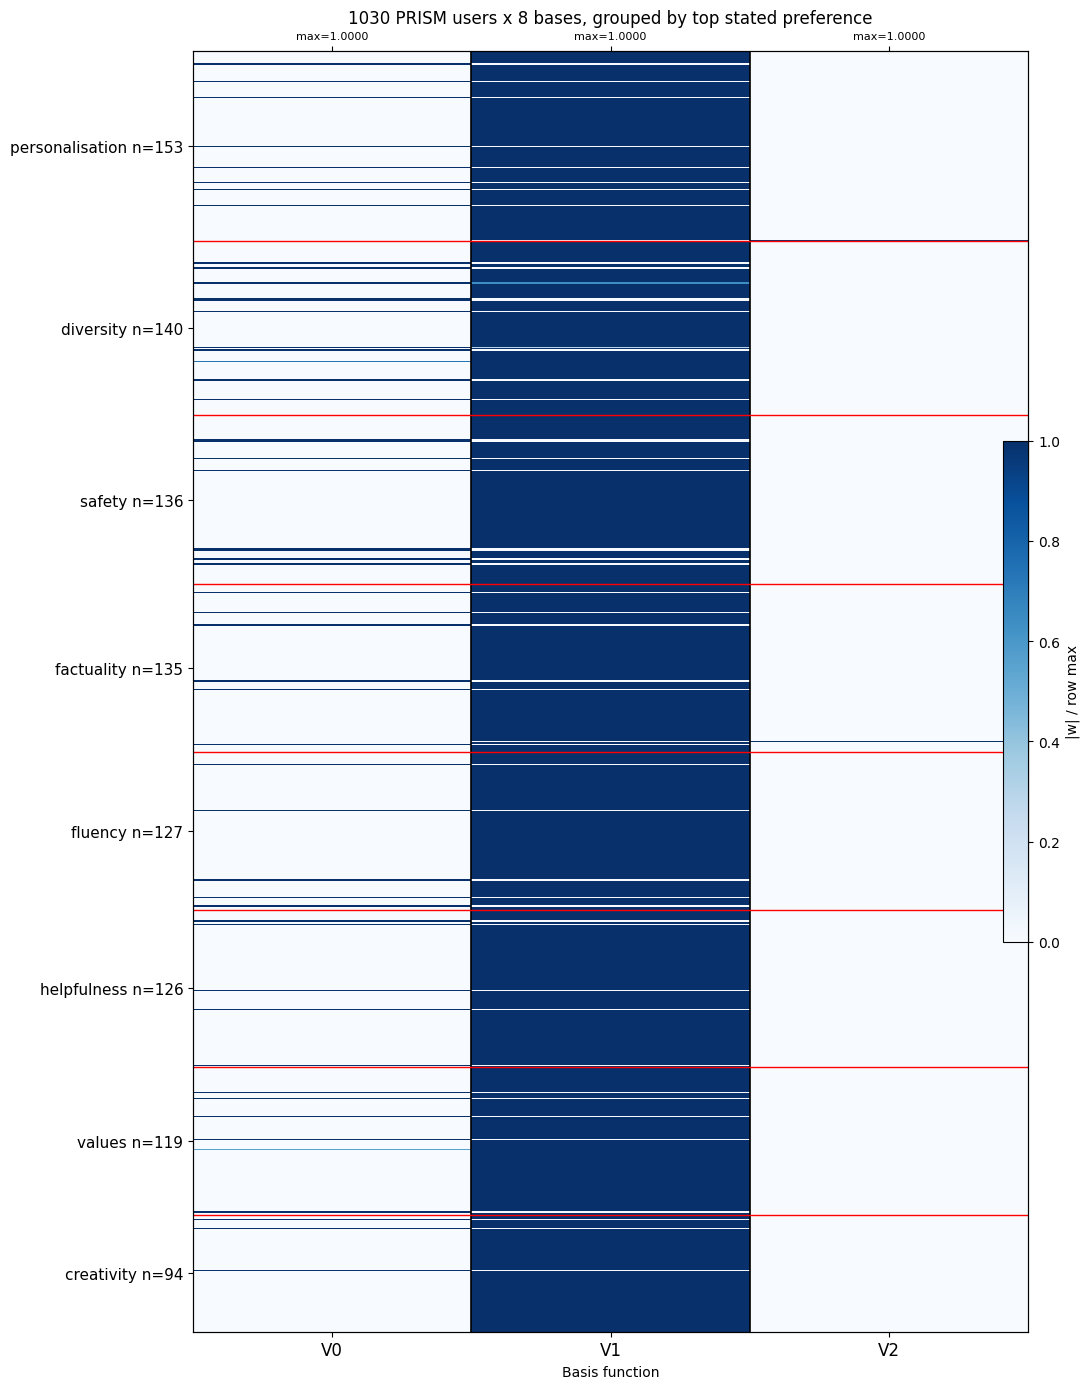

In [11]:
  import matplotlib.pyplot as plt
  import numpy as np
  from collections import Counter

  def get_label(uid):
      raw = user_to_top_pref.get(uid, 'unknown')
      return LABEL_MAP.get(raw, raw)

  labels = [get_label(u) for u in user_ids]
  group_counts = Counter(labels)
  groups = [g for g, _ in group_counts.most_common()]

  idx_by_group = {g: [i for i, l in enumerate(labels) if l == g]
  for g in groups}
  order = []
  boundaries = []
  for g in groups:
      order.extend(idx_by_group[g])
      boundaries.append(len(order))
  order = np.array(order)

  absW = np.abs(W[order])
  row_max = absW.max(axis=1, keepdims=True)
  W_norm = absW / np.maximum(row_max, 1e-12)

  col_max = np.abs(W).max(axis=0)

  fig, ax = plt.subplots(figsize=(11, 14))
  ax.set_facecolor('#dddddd')
  im = ax.imshow(W_norm, aspect='auto', cmap='Blues', vmin=0,
  vmax=1, interpolation='nearest')

  for k in range(1, K):
      ax.axvline(k - 0.5, color='black', linewidth=1.2)

  ax.set_xticks(range(K))
  ax.set_xticklabels(['V' + str(i) for i in range(K)], fontsize=12)
  ax.set_xlabel('Basis function')

  ax_top = ax.twiny()
  ax_top.set_xlim(ax.get_xlim())
  ax_top.set_xticks(range(K))
  ax_top.set_xticklabels([f'max={m:.4f}' for m in col_max],
  fontsize=8)

  ytick = []
  ylabels = []
  prev = 0
  for g, b in zip(groups, boundaries):
      mid = (prev + b) / 2 - 0.5
      ytick.append(mid)
      ylabels.append(g + ' n=' + str(b - prev))
      if b < len(order):
          ax.axhline(b - 0.5, color='red', linewidth=1.0)
      prev = b
  ax.set_yticks(ytick)
  ax.set_yticklabels(ylabels, fontsize=11)

  ax.set_title('1030 PRISM users x 8 bases, grouped by top stated preference', pad=20)
  plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='|w| / row max')
  plt.tight_layout()
  plt.show()

  ## What I observed and what to investigate next               
                                                                   
  ### Current state (this notebook)
                                                                   
  Reproduced APA Stage 1 end-to-end on the 1029-annotator PRISM    
  cohort the paper describes, using Freedman's code unmodified at  
  her published hyperparameters (alpha=10000, K=8, 20000           
  iterations, lr=0.5, min_dialogs > 5,                             
  Skywork-Reward-Llama-3.1-8B-v0.2 embeddings). The resulting
  weight matrix `W_seen_K8.pt` has shape **(1030, 3)** — Freedman's
   `LoReTrainer` applies an automatic pruning threshold of 1e-2 (1%
   of max) during training and drops basis dimensions whose max
  weight stays below that. In our run, 5 of the 8 dimensions
  collapsed below threshold and were removed; only 3 survived.

  For comparison, Freedman's published `W_seen_K8.pt` shipped in   
  the APA repository has shape **(182, 8)** — all 8 bases survived
  in her published training. Every one of her 8 columns has max    
  ~0.02 and mean ~0.005. The visualization function              
  `fig_user_weights_grid` she uses applies no additional filtering
  at plot time — it loads W and plots whatever columns are there.
  So her visible 8-column figure reflects a training outcome that
  kept all 8 alive, not a visualization choice.

  ### Why might this collapse be happening?

  Several plausible mechanisms, in roughly increasing order of     
  "fundamental":
                                                                   
  1. **Random initialization.** Freedman's training code does not  
  set a global torch seed before constructing `LoReTrainer`. The
  Linear layer holding V is initialized via PyTorch's default      
  Kaiming-uniform, which is random. Different random V_init values
  can converge to different local minima — some keep all 8
  dimensions above the pruning threshold, others collapse to 3-4.
  The published 182-user run may simply have happened to land in a
  non-collapsing minimum.

  2. **User-count vs regularization balance.** The loss is `NLL +  
  alpha * ||V - V_sft||²`. With 1030 users and tiny per-user
  gradient signal (~10 pairs per user on average), the             
  regularization term dominates relative to per-dimension        
  likelihood improvement. We tested a stricter user filter
  (min_pairs > 13, yielding ~200 users similar in size to her 182)
  and the collapse persisted (still 3/8 surviving), so user count
  alone is not the cause.

  3. **Embedding-side numeric differences.** Her training was done
  at some unknown transformers/PyTorch version on her cluster; we
  pinned `transformers==4.45.0` to match the API her code expects,
  but exact floating-point behavior of Skywork forward passes    
  differs slightly between versions. Small embedding differences
  can change gradient direction enough to push the optimizer toward
   a different basin.

  4. **Undocumented pre-processing.** Her published 182-row W      
  cannot have come from the documented 1029-user `min_dialogs > 5`
  setting since the row counts disagree. She likely used a stricter
   filter (or earlier prototype run) that she did not commit to the
   repository. Reproducing her exact 182-user setting may require
  an undocumented filtering step.

  ### Two parallel next-step directions                            
  
  **Direction A: Attach human-readable labels to the surviving     
  basis columns.** Each V_k is a 4096-dim direction in Skywork   
  embedding space, semantically opaque on its own. The standard    
  interpretability procedure is: for each `V_k`, compute the scalar
   `V_k · embedding(text)` over every (prompt, chosen-response)
  pair in `train.pkl`, sort by score, and read the top-20 and
  bottom-20 prompts. Patterns in those extreme texts should reveal
  what `V_k` actually encodes (helpfulness? caution? verbosity?
  specific topic?). All artifacts needed for this are already
  saved: `V_K8.pt` + `train.pkl` (which contains both 4096-dim
  Skywork embeddings AND the original prompt/response text for
  every entry). No retraining required — pure offline analysis.

  **Direction B: Understand and reduce the collapse.** Two concrete
   experiments:
                                                                   
  - **Disable pruning to see all 8 columns.** Re-train with        
  `threshold=0` in `LoReTrainer`. The saved W will have all 8
  columns regardless of their magnitude. We can then visualize the
  "would-be-pruned" 5 columns directly and see whether they are  
  truly zero (real collapse) or just below the 0.01 threshold but
  still carrying small structure. This distinguishes "5 dead bases"
   from "5 quiet bases."

  - **Random-init sweep.** Run the same training pipeline with     
  `torch.manual_seed(s)` for several seeds and count how many bases
   survive in each. If the surviving-count varies from 3 to 8      
  across seeds, then her published 8/8 was lucky-init and the    
  collapse is non-deterministic. If all seeds collapse to ≈3, then
  the collapse is a deterministic property of training at this user
   count and alpha.

  - **Sweep K and alpha.** Each combination is fast to test once   
  embeddings exist. The LoRe paper does a K-sweep
  [0,1,5,10,15,20,25,50]; the paper itself never reports K=8       
  specifically. K=25 might preserve more useful structure simply
  because the optimization has more degrees of freedom; lower alpha
   would weaken the pull toward V_sft and let more directions stay
  distinct.

  ### What this proves about LoRe at this scale                    
  
  Even with Freedman's exact code and documented hyperparameters,  
  training on the full PRISM cohort produces a model where 5 of 8
  nominally-allocated bases collapse and get pruned. The effective
  rank of personalization survived is 3. This is itself an       
  interesting empirical observation: the K=8 setting Freedman uses
  may overstate the actual rank of personality variance LoRe can
  extract from PRISM at this regularization. A K-sweep with
  disabled pruning would surface whether the true effective rank is
   3, or whether the survivors hide additional structure suppressed
   by alpha=10000.

In [9]:
  from collections import defaultdict
  import torch
  from pathlib import Path

  DRIVE = Path('/content/drive/MyDrive/LoRe_interp_results')
  train_emb = torch.load(DRIVE / 'train.pkl', weights_only=False)

  seen_pairs = defaultdict(int)
  for ex in train_emb:
      info = ex.get('extra_info', {})
      if info.get('seen') is True and info.get('split') == 'train':
          ce = info.get('chosen_conv_embedding')
          re = info.get('rejected_conv_embedding')
          if ce is not None and re is not None:
              seen_pairs[info['user_id']] += 1

  print('min_pairs | users (target ~182)')
  print('----------+-------')
  for thresh in range(5, 31):
      count = sum(1 for n in seen_pairs.values() if n >= thresh)
      marker = '  <-- closest' if abs(count - 182) < 15 else ''
      print(f'   >= {thresh:3d}  | {count}{marker}')

min_pairs | users (target ~182)
----------+-------
   >=   5  | 1030
   >=   6  | 1030
   >=   7  | 929
   >=   8  | 790
   >=   9  | 651
   >=  10  | 514
   >=  11  | 380
   >=  12  | 290
   >=  13  | 204
   >=  14  | 151
   >=  15  | 111
   >=  16  | 89
   >=  17  | 61
   >=  18  | 44
   >=  19  | 30
   >=  20  | 17
   >=  21  | 13
   >=  22  | 8
   >=  23  | 4
   >=  24  | 2
   >=  25  | 2
   >=  26  | 2
   >=  27  | 2
   >=  28  | 2
   >=  29  | 2
   >=  30  | 2


In [10]:
  import os, sys, subprocess

  if not os.path.exists('/content/LoRe_interp/apa/apa/__init__.py'):
      subprocess.run(['rm', '-rf', '/content/LoRe_interp'],
  check=True)
      subprocess.run(['git', 'clone',
  'https://github.com/ifesiTinkering/LoRe_interp.git',
  '/content/LoRe_interp'], check=True)

  sys.path.insert(0, '/content/LoRe_interp/apa')

  for mod in list(sys.modules.keys()):
      if mod == 'apa' or mod.startswith('apa.'):
          del sys.modules[mod]

  from apa.train_lore_bases import run_regularized
  print('apa import OK')

apa import OK


In [ ]:
  import torch, gc, json, sys
  from pathlib import Path
  from collections import defaultdict

  sys.path.insert(0, '/content/LoRe_interp/apa')
  from apa.train_lore_bases import run_regularized
  from transformers import AutoModel

  DRIVE = Path('/content/drive/MyDrive/LoRe_interp_results')
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  print('device:', device)

  train_emb = torch.load(DRIVE / 'train.pkl', weights_only=False)
  test_emb  = torch.load(DRIVE / 'test.pkl',  weights_only=False)

  def group_filtered(embs, seen_value, split, min_pairs):
      grouped = defaultdict(list)
      for ex in embs:
          info = ex.get('extra_info', {})
          if info.get('seen') == seen_value and info.get('split') == split:
              ce = info.get('chosen_conv_embedding')
              re = info.get('rejected_conv_embedding')
              if ce is None or re is None:
                  continue
              c = torch.tensor(ce, dtype=torch.float32,
  device=device)
              r = torch.tensor(re, dtype=torch.float32,
  device=device)
              grouped[info['user_id']].append(c - r)
      out_W, out_uids = [], []
      for uid in sorted(grouped.keys()):
          if len(grouped[uid]) >= min_pairs:
              out_W.append(torch.stack(grouped[uid]))
              out_uids.append(uid)
      return out_W, out_uids

  print('Loading Skywork for V_sft...')
  rm = AutoModel.from_pretrained(
      'Skywork/Skywork-Reward-Llama-3.1-8B-v0.2',
      torch_dtype=torch.bfloat16, device_map='cpu',
      attn_implementation='eager', num_labels=1,
  low_cpu_mem_usage=True,
  )
  last_linear = None
  for _, m in rm.named_modules():
      if isinstance(m, torch.nn.Linear):
          last_linear = m
  V_sft = last_linear.weight[:,
  0].to(device).to(torch.float32).reshape(-1, 1)
  del rm
  gc.collect()

  results = {}
  for MIN_PAIRS in [13, 14]:
      print(f'\n===== MIN_PAIRS = {MIN_PAIRS} =====')
      train_seen,   uids_seen   = group_filtered(train_emb, True,
  'train', MIN_PAIRS)
      train_unseen, uids_unseen = group_filtered(train_emb, False,
  'train', MIN_PAIRS)
      test_seen,    _           = group_filtered(test_emb,  True,
  'test',  0)
      test_unseen,  _           = group_filtered(test_emb,  False,
  'test',  0)
      print(f'seen users: {len(uids_seen)}, unseen users: {len(uids_unseen)}')

      OUT = Path('/content/checkpoints_min' + str(MIN_PAIRS))
      OUT.mkdir(parents=True, exist_ok=True)

      run_regularized(
          K_list=[8], alpha_list=[10000.0], V_final=V_sft,
          train_features=train_seen,
  test_features_sparse=test_seen,
          train_features_unseen=train_unseen,
  test_features_sparse_unseen=test_unseen,
          N=len(train_seen), N_unseen=len(train_unseen),
  device=device,
          checkpoint_dir=OUT, num_iterations=20000,
  learning_rate=0.5,
          few_shot_iterations=500, few_shot_lr=0.5,
  log_interval=2000,
      )

      W_new = torch.load(OUT / 'W_seen_K8.pt', map_location='cpu',
  weights_only=False).float().numpy()
      print(f'\nResult at MIN_PAIRS={MIN_PAIRS}: W shape = {W_new.shape}')
      print('Per-column max:')
      for k in range(W_new.shape[1]):
          print(f'  V{k}: max={abs(W_new[:, k]).max():.4f}')

      with open(OUT / 'uids.json', 'w') as f:
          json.dump(uids_seen, f, indent=2)

      results[MIN_PAIRS] = (W_new.shape, [abs(W_new[:, k]).max()
  for k in range(W_new.shape[1])])

  print('\n===== SUMMARY =====')
  for mp, (shape, maxes) in results.items():
      print(f'MIN_PAIRS={mp}: W shape={shape}, surviving bases={shape[1]}, col maxes={[f"{m:.3f}" for m in maxes]}')

device: cuda
Loading Skywork for V_sft...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaModel LOAD REPORT from: Skywork/Skywork-Reward-Llama-3.1-8B-v0.2
Key          | Status     |  | 
-------------+------------+--+-
score.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



===== MIN_PAIRS = 13 =====


/tmp/ipykernel_22803/351810150.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c = torch.tensor(ce, dtype=torch.float32,
/tmp/ipykernel_22803/351810150.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r = torch.tensor(re, dtype=torch.float32,


seen users: 204, unseen users: 51
[2026-05-24 17:24:54] Alpha: 10000.0
[2026-05-24 17:24:54] 
[2026-05-24 17:24:54] ==================================================
[2026-05-24 17:24:54] Training K=8, alpha=10000.0
[2026-05-24 17:24:54] ==================================================
